# Creating a Generalized Erasure error correcting Code from kicked Ising Dynamics.

## Unitary for evolving the initial $ \ket{0}  $ state

$$
U \;=\;
\exp\!\biggl(-\,i\frac{\pi}{4}\sum_{j=1}^{L-1}X_j\,X_{j+1}\biggr)
\;\exp\!\biggl(-\,i\frac{\pi}{4}\sum_{j=1}^{L}Z_j\biggr).
$$
$U = \prod_j A_{j,j+1} \, \prod_j B_j$

$$
A_j = \frac{1}{\sqrt{2}}\left(I - i X_j X_{j+1}\right), \quad
B_j = \frac{1}{\sqrt{2}}\left(I - i Z_j\right)
$$


### using qiskit

Subsystem entropy S(ψ_{L/4}) keeping qubits [0, 1, 2, 3]: 4.000000 bits


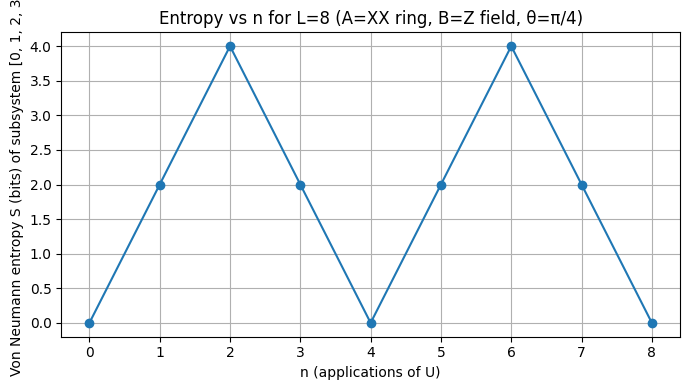

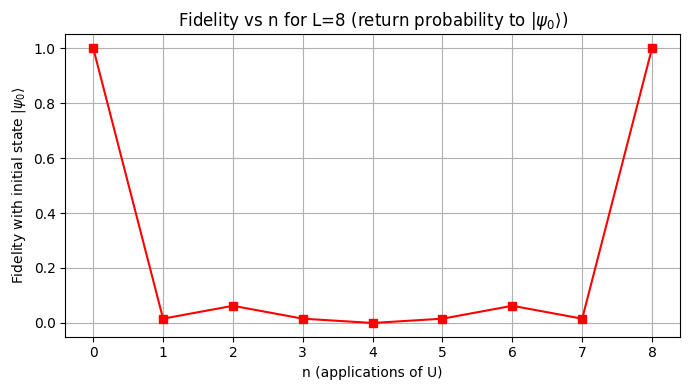

[1.0, 0.015625000000000007, 0.06250000000000003, 0.015625000000000007, 0.0, 0.015625000000000007, 0.06250000000000003, 0.015625000000000007, 1.0000000000000004]


In [6]:
#qiskit code 
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace,DensityMatrix,state_fidelity
from qiskit.quantum_info.states.measures import entropy as von_neumann_entropy

# ---- Parameters ----
L = 8
theta = np.pi / 4
n_max = L                 # evaluate n = 0..L
keep = list(range(4))     # keep first 6 qubits (0..5)
trace_out = [q for q in range(L) if q not in keep]
steps_for_target = L // 4 # to get ψ_{L/4}

# ---- Exact circuit for U = A·B ----
def circuit_for_B(L, theta):
    qc = QuantumCircuit(L, name="B")
    # B = exp(-i theta sum Z_j) = ∏ RZ(2θ)
    for j in range(L):
        qc.rz(2 * theta, j)
    return qc


def circuit_for_A_xx_ring(L, theta, periodic=True):
    """
    Build A = exp(-i theta ∑ X_j X_{j+1}) using Qiskit RXXGate.

    RXX(phi) = exp(-i (phi/2) X⊗X), so to get exp(-i theta X⊗X),
    we set phi = 2 * theta.
    """
    qc = QuantumCircuit(L, name="A_xx_RXX")
    phi = 2 * theta  # match exp(-i theta X⊗X) form
    if periodic:
        # periodic boundary includes (L-1, 0)
        for j in range(L):
            k = (j + 1) % L
            qc.rxx(phi, j, k)
    else:
        # open chain
        for j in range(L - 1):
            qc.rxx(phi, j, j + 1)
    return qc


qc_U = QuantumCircuit(L, name="U_layer")
qc_U.compose(circuit_for_A_xx_ring(L, theta), inplace=True)
qc_U.compose(circuit_for_B(L, theta), inplace=True)

# ---- Evolve ψ_n = U^n |0...0> and compute S(ρ_sub(n)) ----
entropies = []
fidilities = []
psi = Statevector.from_label("0" * L)  # ψ_0
# n = 0
rho_full = DensityMatrix(psi)
rho_sub = partial_trace(rho_full, trace_out)
S0 = float(von_neumann_entropy(rho_sub, base=2))
entropies.append(S0)
psi_0 = psi.copy()
fidelity = state_fidelity(psi, psi_0)
fidilities.append(fidelity)

# n = 1..n_max
for n in range(1, n_max + 1):
    psi = psi.evolve(qc_U)
    rho_full = DensityMatrix(psi)
    rho_sub = partial_trace(rho_full, trace_out)
    S = float(von_neumann_entropy(rho_sub, base=2))
    entropies.append(S)
    fidelity = state_fidelity(psi, psi_0)
    fidilities.append(fidelity)
    

# ---- Report S at n = L/4 ----
S_L_over_4 = entropies[steps_for_target]
print(f"Subsystem entropy S(ψ_{{L/4}}) keeping qubits {keep}: {S_L_over_4:.6f} bits")

# ---- Plot ----
plt.figure(figsize=(7,4))
plt.plot(range(0, n_max + 1), entropies, marker='o')
plt.xlabel('n (applications of U)')
plt.ylabel('Von Neumann entropy S (bits) of subsystem ' + str(keep))
plt.title(f'Entropy vs n for L={L} (A=XX ring, B=Z field, θ=π/4)')
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Plot Fidelity vs n ----
plt.figure(figsize=(7,4))
plt.plot(range(0, n_max + 1), fidilities, marker='s', color='red')
plt.xlabel('n (applications of U)')
plt.ylabel(r'Fidelity with initial state $|\psi_0⟩$')
plt.title(rf'Fidelity vs n for L={L} (return probability to $|\psi_0⟩$)')

plt.grid(True)
plt.tight_layout()
plt.show()
print(fidilities)


we can see that the nature of the state at $ n = \frac{L}{4}$ is maximally entangle for a $\frac{L}{2}$ subsystem.

### Finding the stabilizers for the $ \frac{L}{2}$ block entagled state.

In [7]:
#stabilizers ,and show that they stabilize with state,  all errors that can be solved in a L/2 known region with phi
import numpy as np
import itertools

# === PAULI DICTIONARIES ===
PAULI_TO_XZ = {'I': (0, 0), 'X': (1, 0), 'Z': (0, 1), 'Y': (1, 1)}
XZ_TO_PAULI = {(0, 0): 'I', (1, 0): 'X', (0, 1): 'Z', (1, 1): 'Y'}

# === STABILIZER EVOLUTION ===
def evolve_single_qubit_A(op):
    evolution = {'I': ('I', 1), 'X': ('Y', 1), 'Y': ('X', -1), 'Z': ('Z', 1)}
    return evolution[op]

def evolve_two_qubit_B(op1, op2):
    table = {
        ('I','I'):('I','I',1), ('I','X'):('I','X',1), ('I','Y'):('X','Z',1), ('I','Z'):('X','Y',-1),
        ('X','I'):('X','I',1), ('X','X'):('X','X',1), ('X','Y'):('I','Z',1), ('X','Z'):('I','Y',-1),
        ('Y','I'):('Z','X',1), ('Y','X'):('Z','I',1), ('Y','Y'):('Y','Y',1), ('Y','Z'):('Y','Z',1),
        ('Z','I'):('Y','X',-1),('Z','X'):('Y','I',-1),('Z','Y'):('Z','Y',1),('Z','Z'):('Z','Z',1)
    }
    return table[(op1, op2)]

def generate_stabilizer_matrix(L):
    return [['Z' if i == j else 'I' for j in range(L)] for i in range(L)]

def apply_A_evolution(stabilizer):
    evolved = []
    coeff = 1
    for op in stabilizer:
        e_op, e_coeff = evolve_single_qubit_A(op)
        evolved.append(e_op)
        coeff *= e_coeff
    return evolved, coeff

def apply_B_evolution(stabilizer, pairs):
    evolved = stabilizer[:]
    coeff = 1
    for q1, q2 in pairs:
        op1, op2 = evolved[q1], evolved[q2]
        e1, e2, c = evolve_two_qubit_B(op1, op2)
        evolved[q1], evolved[q2] = e1, e2
        coeff *= c
    return evolved, coeff

def generate_qubit_pairs(L):
    return [(i, (i + 1) % L) for i in range(L)]

def evolve_stabilizer_matrix_multiple_U(matrix, pairs, n):
    evolved = matrix[:]
    for _ in range(n):
        for idx, stab in enumerate(evolved):
            stab, c1 = apply_A_evolution(stab)
            stab, c2 = apply_B_evolution(stab, pairs)
            evolved[idx] = stab
    return evolved

def stabilizer_to_tableau_row(row):
    X = [PAULI_TO_XZ[op][0] for op in row]
    Z = [PAULI_TO_XZ[op][1] for op in row]
    return X + Z

# === MAIN LOGIC ===
L, n = 8,2
stab_mat = generate_stabilizer_matrix(L)
pairs = generate_qubit_pairs(L)
evolved = evolve_stabilizer_matrix_multiple_U(stab_mat, pairs, n)
stab_tableau = np.array([stabilizer_to_tableau_row(row) for row in evolved]) 
for i in evolved:
    print(i)
print(stab_tableau)

['Z', 'Z', 'X', 'I', 'I', 'I', 'X', 'Z']
['Z', 'Z', 'Z', 'X', 'I', 'I', 'I', 'X']
['X', 'Z', 'Z', 'Z', 'X', 'I', 'I', 'I']
['I', 'X', 'Z', 'Z', 'Z', 'X', 'I', 'I']
['I', 'I', 'X', 'Z', 'Z', 'Z', 'X', 'I']
['I', 'I', 'I', 'X', 'Z', 'Z', 'Z', 'X']
['X', 'I', 'I', 'I', 'X', 'Z', 'Z', 'Z']
['Z', 'X', 'I', 'I', 'I', 'X', 'Z', 'Z']
[[0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1]
 [0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0]
 [0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0]
 [0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0]
 [1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1]
 [0 1 0 0 0 1 0 0 1 0 0 0 0 0 1 1]]


### generating errors and checking for syndromes

In [8]:

def generate_errors(L, start):
    max_weight = L //2 
    block_size = L // 2 
    paulis = ['X', 'Y', 'Z']
    region = [(start + i) % L for i in range(block_size)]
    errors = []

    for w in range(1, max_weight + 1):
        for pos in itertools.combinations(region, w):
            for ops in itertools.product(paulis, repeat=w):
                err = ['I'] * L
                for p, o in zip(pos, ops):
                    err[p] = o
                errors.append(err)
    errors.append(['I'] * L)
    return errors


errors = generate_errors(L, start=0) # correct
print(len(errors))
for i in errors[:5]:
    print(i)

errors_tableau = [stabilizer_to_tableau_row(err) for err in errors]

256
['X', 'I', 'I', 'I', 'I', 'I', 'I', 'I']
['Y', 'I', 'I', 'I', 'I', 'I', 'I', 'I']
['Z', 'I', 'I', 'I', 'I', 'I', 'I', 'I']
['I', 'X', 'I', 'I', 'I', 'I', 'I', 'I']
['I', 'Y', 'I', 'I', 'I', 'I', 'I', 'I']


In [12]:
def tableau_to_stabilizer(tableau_row):
    """Converts a tableau row back to a stabilizer string."""
    L = len(tableau_row) // 2
    X_part = tableau_row[0:L]
    Z_part = tableau_row[L:2*L]  # ← fix: slice correctly
    pauli_string = ''.join(XZ_TO_PAULI[(x, z)] for x, z in zip(X_part, Z_part))
    return pauli_string


def multiply_tableau(rows):
    return np.bitwise_xor.reduce(rows, axis=0)

def commutation(A, B, L):
    Ax, Az = A[:L], A[L:]
    Bx, Bz = B[:L], B[L:]
    return 1 if (np.dot(Ax, Bz) + np.dot(Az, Bx)) % 2 == 0 else -1


syndrome_table = {}

for i, err in enumerate(errors_tableau):
    # print(i , err, errors[i])
    syn = tuple(commutation(err, s, L) for s in stab_tableau)  # Compute syndrome
    # print(syn)
    if syn in syndrome_table:
        syndrome_table[syn].append(errors[i])  # Store the readable Pauli error
    else:
        syndrome_table[syn] = [errors[i]]


# 1. Analyze the entire dictionary for uniqueness
total_syndromes = len(syndrome_table)
duplicate_syndromes_count = sum(1 for err_list in syndrome_table.values() if len(err_list) > 1)

# 2. Print the global summary
print("=== GLOBAL SYNDROME UNIQUENESS REPORT ===")
if duplicate_syndromes_count == 0:
    print(f"Result: All syndromes are UNIQUE! (Total: {total_syndromes} syndromes, each maps to exactly 1 error).")
else:
    print(f"Result: Contains DUPLICATE errors!")
    print(f"  - Total unique syndrome buckets: {total_syndromes}")
    print(f"  - Syndromes with degenerate/duplicate errors: {duplicate_syndromes_count}")
print("=" * 41 + "\n")

# 3. Print only the first 5 elements for inspection
print("=== SHOWING FIRST 5 ELEMENTS ===")
for i, (syn, err_list) in enumerate(syndrome_table.items()):
    if i >= 5:
        break
        
    num_errors = len(err_list)
    print(f"Syndrome {syn}:")
    if num_errors > 1:
        print(f"  [DUPLICATES FOUND - {num_errors} errors]:")
        for e in err_list:
            print('    ', ''.join(e))
    else:
        print(f"  [UNIQUE]: {''.join(err_list[0])}")
    print("-" * 30)
    

=== GLOBAL SYNDROME UNIQUENESS REPORT ===
Result: All syndromes are UNIQUE! (Total: 256 syndromes, each maps to exactly 1 error).

=== SHOWING FIRST 5 ELEMENTS ===
Syndrome (-1, -1, 1, 1, 1, 1, 1, -1):
  [UNIQUE]: XIIIIIII
------------------------------
Syndrome (-1, -1, -1, 1, 1, 1, -1, -1):
  [UNIQUE]: YIIIIIII
------------------------------
Syndrome (1, 1, -1, 1, 1, 1, -1, 1):
  [UNIQUE]: ZIIIIIII
------------------------------
Syndrome (-1, -1, -1, 1, 1, 1, 1, 1):
  [UNIQUE]: IXIIIIII
------------------------------
Syndrome (-1, -1, -1, -1, 1, 1, 1, -1):
  [UNIQUE]: IYIIIIII
------------------------------


we can see that all errors in a $\frac{L}{2} $ consecutive qubit region have unique syndromes

##  Building a Code Space with CX Gates

We consider an L-qubit state $$|\phi\rangle$$ with stabilizers:
$$
S_i = X_i Z_{i+1} Z_{i+2} \cdots Z_{i+L/2-1} X_{i+L/2}
$$

It can be shown that $$|\phi\rangle$$ is orthogonal to $$X_1 X_2 \cdots X_L |\phi\rangle$$. Both states have identical entanglement properties and can be transformed into each other via local unitaries.

A logical qubit can be encoded into the span of these two states by replacing the CZ gates with CX gates.

---

### Encoded State
$$
|e\rangle = \alpha |\phi\rangle + \beta X_L |\phi\rangle, 
\quad X_L = X_1 X_2 \cdots X_L
$$

All \(S_i\) anti-commute with \(X_L\). Therefore, products of adjacent stabilizers commute with \(X_L\):
$$
S_i' = S_i S_{i+1} = X_i Y_{i+1} Y_{i+L/2-1} X_{i+L/2}
$$

---



### Error Correction Check



In [13]:
# errors on L//2 -1 consecutive qubits.
def generate_errors_1(L, start):
    max_weight = L //2 -1
    block_size = L // 2 -1
    paulis = ['X', 'Y', 'Z']
    region = [(start + i) % L for i in range(block_size)]
    errors = []

    for w in range(1, max_weight + 1):
        for pos in itertools.combinations(region, w):
            for ops in itertools.product(paulis, repeat=w):
                err = ['I'] * L
                for p, o in zip(pos, ops):
                    err[p] = o
                errors.append(err)
    errors.append(['I'] * L)
    return errors


errors_1 = generate_errors_1(L, start=0) # correct
print(len(errors))
for i in errors[:5]:
    print(i)

errors_tableau_1 = [stabilizer_to_tableau_row(err) for err in errors_1]

256
['X', 'I', 'I', 'I', 'I', 'I', 'I', 'I']
['Y', 'I', 'I', 'I', 'I', 'I', 'I', 'I']
['Z', 'I', 'I', 'I', 'I', 'I', 'I', 'I']
['I', 'X', 'I', 'I', 'I', 'I', 'I', 'I']
['I', 'Y', 'I', 'I', 'I', 'I', 'I', 'I']


In [14]:
#creating code space , new stabilizers , errors that can be solved in a L/2 known region.


def gen_combinations(anti):
    return np.array([multiply_tableau([anti[i], anti[(i+1)%len(anti)]]) for i in range(len(anti)-1)])

def new_generators(z_comm, stabilizer_gen):
    mask = (z_comm == 0)
    comm = stabilizer_gen[mask]
    anti = stabilizer_gen[~mask]
    combined = gen_combinations(anti)
    return np.vstack([comm, combined])

Z_given = ['X']*L
# Z_given = ['I', 'Y', 'Y', 'Y', 'Y', 'Z', 'Z', 'Y', 'Y', 'Y', 'Y', 'I']
print(f'Used X_L:{Z_given}')
Z_given_tab = stabilizer_to_tableau_row(Z_given)

z_comm = np.array([0 if commutation(Z_given_tab, s, L) == 1 else 1 for s in stab_tableau])
print(f'z_comm = {z_comm}. 0 for commuting ,1 for non-commuting of the X_L with the stabilizers of the state.')
new_gen = new_generators(z_comm, stab_tableau)

print("\n")
print('new generators')
for gen in new_gen:
    print(list(tableau_to_stabilizer(gen)))

syndrome_table = {}

for i, err in enumerate(errors_tableau_1):
    # print(i , err, errors[i])
    syn = tuple(commutation(err, s, L) for s in new_gen)  # Compute syndrome
    # print(syn)
    if syn in syndrome_table:
        syndrome_table[syn].append(errors[i])  # Store the readable Pauli error
    else:
        syndrome_table[syn] = [errors[i]]


print("\n")
print("the errors with same syndromes:")
# Optional: Print the syndrome table
for syn, err_list in syndrome_table.items():
    if len(err_list)>1:
        print(f"Syndrome {syn}:")
        for e in err_list:
            print('  ', ''.join(e))


Used X_L:['X', 'X', 'X', 'X', 'X', 'X', 'X', 'X']
z_comm = [1 1 1 1 1 1 1 1]. 0 for commuting ,1 for non-commuting of the X_L with the stabilizers of the state.


new generators
['I', 'I', 'Y', 'X', 'I', 'I', 'X', 'Y']
['Y', 'I', 'I', 'Y', 'X', 'I', 'I', 'X']
['X', 'Y', 'I', 'I', 'Y', 'X', 'I', 'I']
['I', 'X', 'Y', 'I', 'I', 'Y', 'X', 'I']
['I', 'I', 'X', 'Y', 'I', 'I', 'Y', 'X']
['X', 'I', 'I', 'X', 'Y', 'I', 'I', 'Y']
['Y', 'X', 'I', 'I', 'X', 'Y', 'I', 'I']


the errors with same syndromes:


we can see that after encoding the code can correct all errors in a $\frac{L}{2}-1$ region.

### finding logical operators for the encoded code.

In [40]:
#set for the universal gates for the code space 1 logical qubit of L normal qubits
import numpy as np
from math import pi
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, Pauli, Operator

# ===== Parameters =====
L = 12
theta = np.pi / 4
steps_for_target = L // 4  # evolve to psi_{L/4}

# ===== Build U = A · B =====
def circuit_for_A_xx_ring(L, theta, periodic=True):
    qc = QuantumCircuit(L, name="A_xx_RXX")
    phi = 2 * theta
    if periodic:
        for j in range(L):
            qc.rxx(phi, j, (j + 1) % L)
    else:
        for j in range(L - 1):
            qc.rxx(phi, j, j + 1)
    return qc

def circuit_for_B(L, theta):
    qc = QuantumCircuit(L, name="B")
    for j in range(L):
        qc.rz(2 * theta, j)
    return qc

# Build full U = A then B
qc_U = QuantumCircuit(L, name="U")
qc_U.compose(circuit_for_A_xx_ring(L, theta), inplace=True)
qc_U.compose(circuit_for_B(L, theta), inplace=True)

# ===== 1. Build initial state =====
psi = Statevector.from_label("0" * L)

# ===== 2. Evolve to psi_{L/4} =====
for _ in range(steps_for_target):
    psi = psi.evolve(qc_U)
psi_L_over_4 = psi.copy()

# ===== 3. Build logical states =====
X_L_op = SparsePauliOp(Pauli("X" * L))
Z_L_str = "XZZZZZXIIIII"  # Provided logical Z
assert len(Z_L_str) == L
Z_L_op = SparsePauliOp(Pauli(Z_L_str))

ket0L = psi_L_over_4
ket1L = ket0L.evolve(Operator(X_L_op))

# ===== Utilities =====
def overlap(psi_a: Statevector, psi_b: Statevector):
    return complex(np.vdot(psi_a.data, psi_b.data))

def expectation_pauli(state: Statevector, pauli: SparsePauliOp):
    return state.expectation_value(Operator(pauli))

def print_check(label, value, target=None, atol=1e-8):
    if target is None:
        print(f"{label}: {value}")
    else:
        ok = np.allclose(value, target, atol=atol)
        print(f"{label}: {value}  | target: {target}  -> {'OK' if ok else 'FAIL'}")

# ===== 4. Check logical basis =====
print("==== Logical basis checks ====")
print_check("⟨0_L|0_L⟩", np.vdot(ket0L.data, ket0L.data).real, 1.0)
print_check("⟨1_L|1_L⟩", np.vdot(ket1L.data, ket1L.data).real, 1.0)
print_check("|⟨0_L|1_L⟩|", abs(overlap(ket0L, ket1L)), 0.0)

# ===== Check X_L action =====
print("\n==== X_L action ====")
X0 = ket0L.evolve(Operator(X_L_op))
X1 = ket1L.evolve(Operator(X_L_op))
print_check("|⟨1_L|X_L|0_L⟩|", abs(overlap(ket1L, X0)), 1.0)
print_check("|⟨0_L|X_L|1_L⟩|", abs(overlap(ket0L, X1)), 1.0)

# ===== Check Z_L action =====
print("\n==== Z_L action ====")
z00 = expectation_pauli(ket0L, Z_L_op)
z11 = expectation_pauli(ket1L, Z_L_op)
z01 = overlap(ket0L, ket1L.evolve(Operator(Z_L_op)))
print_check("⟨0_L|Z_L|0_L⟩ (≈±1)", z00)
print_check("⟨1_L|Z_L|1_L⟩ (≈∓1)", z11)
print_check("|⟨0_L|Z_L|1_L⟩|", abs(z01), 0.0)
if abs(z00) > 1e-6:
    print(f"Logical Z eigenvalue sign: sign(z00)={np.sign(z00.real):+}")


==== Logical basis checks ====
⟨0_L|0_L⟩: 1.0000000000000004  | target: 1.0  -> OK
⟨1_L|1_L⟩: 1.0000000000000004  | target: 1.0  -> OK
|⟨0_L|1_L⟩|: 0.0  | target: 0.0  -> OK

==== X_L action ====
|⟨1_L|X_L|0_L⟩|: 1.0000000000000004  | target: 1.0  -> OK
|⟨0_L|X_L|1_L⟩|: 1.0000000000000004  | target: 1.0  -> OK

==== Z_L action ====
⟨0_L|Z_L|0_L⟩ (≈±1): (1.0000000000000004+0j)
⟨1_L|Z_L|1_L⟩ (≈∓1): (-1.0000000000000004+0j)
|⟨0_L|Z_L|1_L⟩|: 0.0  | target: 0.0  -> OK
Logical Z eigenvalue sign: sign(z00)=+1.0
